## Speedy Coupling
Todays' weather models are increasingly becoming indistinguishable from climate models, at least from the point of view of construction. Of course weather models are usually run at higher resolution and with large ensembles.

Today we shall: 
- experiment with different levels of coupling of Earth System components:
  - land
  - ocean
- Move to building your own experiment

For the last part, it is important that 
1) you think of a science problem
2) you design a modelling system to answer that question
3) you perform analysis to test your ideas and hypotheses

As always, we start by defining and initialising a model, then we run an experiment. I suggest the PrimitiveEquationWet model, but feel free to choose another one. Also, do remember that each model automatically sets some outputs, but you can modify those, depending on what you want to analyse.

Another idea you may want to explore is whether you want to move into climate simulation. For that, you may want to:
- run for multiple years
- analyse your results by season (which may require writing outputs to NetCDF and then processing the outputs with CDO operators).

The list of currently available Earth System modeuls is here: https://speedyweather.github.io/SpeedyWeatherDocumentation/dev/parameterizations/

## Let us set up a planet with a land/sea mask and realistic orography. 
We start by running at T31, but we aim to run for one year, taking us part of the way into climate modelling.

In [1]:
#using Pkg; Pkg.instantiate(); Pkg.precompile()
#using Pkg; Pkg.add("SpeedyWeather")

In [2]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, output=output)
simulation = initialize!(model)
#run!(simulation, period=Day(365), output=true)
run!(simulation, period=Day(30), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
Weather is speedy: run 0028 100%|█████████| Time: 0:00:07 (940.41 years/day)


                      Surface relative vorticity [1/s]                     
       ┌────────────────────────────────────────────────────────────┐ 4e⁻⁵ 
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄

In [3]:
model.land

LandModel <: SpeedyWeather.AbstractWetLand
├ spectral_grid: SpectralGrid
├ geometry: LandGeometry{Float32, Vector{Float32}}
├ thermodynamics: LandThermodynamics{Float32}
├ temperature: SeasonalLandTemperature{Float32, OctahedralGaussianArray{Float32, 2, Matrix{Float32}}}
├ soil_moisture: SeasonalSoilMoisture{Float32, OctahedralGaussianArray{Float32, 3, Array{Float32, 3}}}
├ vegetation: VegetationClimatology{Float32, OctahedralGaussianGrid{Float32}}
└ rivers: NoRivers

In [4]:
using CairoMakie

(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
precip_large_scale_clim=precip_large_scale
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale_clim, title="Large-scale precipiation [mm]: Accumulated over NN days", colorrange = (0,250), colormap=:dense)
save("Clim_precip.png",fig)

In [5]:
#simulation
#simulation.model.geometry
simulation.model
simulation.model.orography.orography
#simulation.prognostic_variables
#simulation.diagnostic_variables
#simulation.diagnostic_variables.dynamics
#simulation.diagnostic_variables.physics
#simulation.diagnostic_variables.grid

3168-element, 48-ring OctahedralGaussianGrid{Float32}:
   14.983424
   -5.667698
  -16.814646
  -20.29903
  -20.024845
  -18.689304
  -17.529533
  -17.382645
  -19.136171
  -23.095566
  -28.06001
  -31.17983
  -28.984755
    ⋮
 2456.6387
 2227.3223
 2038.6853
 1918.419
 1867.0206
 1860.9578
 1871.1128
 1883.6133
 1908.3062
 1969.998
 2089.5295
 2267.4888

## Now we start experimenting with fluxes from ES components
We start by contrasting a dry land and a wet land. It is useful in this context to add surface fluxes to the output.
You should also consider adding the full land surface output. You can look up what is available under DiagnosticVariables, e.g. look up the group SpeedyWeather.EvaporativeFluxOutput.

In [6]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate_Dry-Land", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)
#surface_evaporation = NoSurfaceEvaporation(spectral_grid)
thermodynamics = LandThermodynamics(spectral_grid, heat_conductivity=0.25)
land = DryLandModel(spectral_grid; thermodynamics)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, land, output=output)
simulation = initialize!(model)
run!(simulation, period=Day(365), output=true)
#run!(simulation, period=Day(30), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
Weather is speedy: run 0029 100%|█████████| Time: 0:01:29 (968.46 years/day)


                      Surface relative vorticity [1/s]                     
       ┌────────────────────────────────────────────────────────────┐ 6e⁻⁵ 
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄

In [7]:
using CairoMakie

(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
precip_large_scale_no_land=precip_large_scale
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale_no_land, title="Large-scale precipiation [mm]: Dry Land Accumulated over NN days", colorrange = (0,250), colormap=:dense)
#fig=contour!(orography.orography)
#oro=orography.orography
#fig=heatmap(oro, title="Large-scale precipiation [mm]: No Evap Accumulated over NN days", colorrange = (0,150), colormap=:dense)
save("DryLand_precip.png",fig)

In [8]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate_WetLand", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)
#surface_evaporation = NoSurfaceEvaporation(spectral_grid)
thermodynamics = LandThermodynamics(spectral_grid, heat_conductivity=0.25)
land = LandModel(spectral_grid; thermodynamics)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, land, output=output)
simulation = initialize!(model)
run!(simulation, period=Day(365), output=true)
#run!(simulation, period=Day(30), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
Weather is speedy: run Climate_WetLand 100% Time: 0:01:26 (994.61 years/day)m


                      Surface relative vorticity [1/s]                     
       ┌────────────────────────────────────────────────────────────┐ 6e⁻⁵ 
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄

In [9]:
using CairoMakie

(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
precip_large_scale_land=precip_large_scale
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale_land, title="Large-scale precipiation [mm]: Wet Land Accumulated over NN days", colorrange = (0,250), colormap=:dense)
#fig=contour!(orography.orography)
#oro=orography.orography
#fig=heatmap(oro, title="Large-scale precipiation [mm]: No Evap Accumulated over NN days", colorrange = (0,150), colormap=:dense)
save("WetLand_precip.png",fig)

In [10]:
model.land

LandModel <: SpeedyWeather.AbstractWetLand
├ spectral_grid: SpectralGrid
├ geometry: LandGeometry{Float32, Vector{Float32}}
├ thermodynamics: LandThermodynamics{Float32}
├ temperature: SeasonalLandTemperature{Float32, OctahedralGaussianArray{Float32, 2, Matrix{Float32}}}
├ soil_moisture: SeasonalSoilMoisture{Float32, OctahedralGaussianArray{Float32, 3, Array{Float32, 3}}}
├ vegetation: VegetationClimatology{Float32, OctahedralGaussianGrid{Float32}}
└ rivers: NoRivers

In [11]:
subtypes(SpeedyWeather.AbstractLand)

2-element Vector{Any}:
 SpeedyWeather.AbstractDryLand
 SpeedyWeather.AbstractWetLand

In [12]:
subtypes(SpeedyWeather.AbstractLandTemperature)

3-element Vector{Any}:
 ConstantLandTemperature
 LandBucketTemperature
 SeasonalLandTemperature

In [13]:
subtypes(SpeedyWeather.AbstractSoilMoisture)

3-element Vector{Any}:
 LandBucketMoisture
 NoSoilMoisture
 SeasonalSoilMoisture

## Now we couple with a land model (a Bucket model)
Until now we had been using a seasonal land climatology, but now we shall allow the land surface to evolve and create fluxes to the atmosphere

In [14]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate_Bucket", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)
#surface_evaporation = NoSurfaceEvaporation(spectral_grid)
thermodynamics = LandThermodynamics(spectral_grid, heat_conductivity=0.25)
temperature=LandBucketTemperature(spectral_grid)
soil_moisture=LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature, soil_moisture)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, land, output=output)
simulation = initialize!(model)
run!(simulation, period=Day(365), output=true)
#run!(simulation, period=Day(30), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
┌ Warning: NaN or Inf detected at time step 10867
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/uxLaK/src/output/feedback.jl:144
Weather is speedy: run 0030 100%|█████████| Time: 0:01:23 (1028.94 years/day)


                      Surface relative vorticity [1/s]                    
       ┌────────────────────────────────────────────────────────────┐  NaN
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄

In [15]:
using CairoMakie

(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
precip_large_scale_land=precip_large_scale
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale_land, title="Large-scale precipiation [mm]: Bucket Land Accumulated over NN days", colorrange = (0,250), colormap=:dense)
#fig=contour!(orography.orography)
#oro=orography.orography
#fig=heatmap(oro, title="Large-scale precipiation [mm]: No Evap Accumulated over NN days", colorrange = (0,150), colormap=:dense)
save("BucketLand_precip.png",fig)

In [16]:
subtypes(SpeedyWeather.AbstractOcean)

4-element Vector{Any}:
 AquaPlanet
 ConstantOceanClimatology
 SeasonalOceanClimatology
 SlabOcean

## Now we couple with a Slab Ocean
Until now we had been using a seasonal ocean climatology, but now we shall allow a shallow ocean to evolve and create fluxes to the atmosphere

In [17]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate_Ocean", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)
#surface_evaporation = NoSurfaceEvaporation(spectral_grid)
thermodynamics = LandThermodynamics(spectral_grid, heat_conductivity=0.25)
temperature=LandBucketTemperature(spectral_grid)
soil_moisture=LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)
# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, land, ocean, output=output)
simulation = initialize!(model)
run!(simulation, period=Day(365), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
Weather is speedy: run 0031 100%|█████████| Time: 0:01:30 (952.53 years/day)m


                      Surface relative vorticity [1/s]                     
       ┌────────────────────────────────────────────────────────────┐ 6e⁻⁵ 
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄

In [18]:
using CairoMakie

(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
precip_large_scale_land_ocean=precip_large_scale
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale_land_ocean, title="Large-scale precipiation [mm]: Slab Ocean and Bucket Land Accumulated over NN days", colorrange = (0,250), colormap=:dense)
#fig=contour!(orography.orography)
#oro=orography.orography
#fig=heatmap(oro, title="Large-scale precipiation [mm]: No Evap Accumulated over NN days", colorrange = (0,150), colormap=:dense)
save("Ocean-BucketLand_precip.png",fig)

In [2]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
model = PrimitiveWetModel(spectral_grid)

PrimitiveWetModel <: PrimitiveWet
├ spectral_grid: SpectralGrid
├ device_setup: SpeedyWeather.DeviceSetup{CPU, DataType}
├ dynamics: Bool
├ geometry: Geometry{Float32, OctahedralGaussianGrid, Vector{Float32}, Vector{Float64}}
├ planet: Earth{Float32}
├ atmosphere: EarthAtmosphere{Float32}
├ coriolis: Coriolis{Float32, Vector{Float32}}
├ geopotential: Geopotential{Float32, Vector{Float32}}
├ adiabatic_conversion: AdiabaticConversion{Float32, Vector{Float32}}
├ particle_advection: NoParticleAdvection
├ initial_conditions: InitialConditions{ZonalWind, PressureOnOrography, JablonowskiTemperature, ConstantRelativeHumidity}
├ forcing: NoForcing
├ drag: NoDrag
├ random_process: NoRandomProcess
├ tracers: Dict{Symbol, Tracer}
├ orography: EarthOrography{Float32, OctahedralGaussianGrid{Float32}, LowerTriangularMatrix{ComplexF32}}
├ land_sea_mask: EarthLandSeaMask{Float32, OctahedralGaussianGrid{Float32}}
├ ocean: SeasonalOceanClimatology{Float32, OctahedralGaussianArray{Float32, 2, Matrix{Float

## Here are a series of ideas about flux denial, to understand what flux causes what evolution, but this requires detailed study of what each option for surface fluxes is doing. Experiment at your own risk!

In [3]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate_No-Ocean-Evap", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip
add!(output,SpeedyWeather.EvaporativeFluxOutput())

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)
surface_evaporation = NoSurfaceEvaporation(spectral_grid)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, surface_evaporation, output=output)
simulation = initialize!(model)
#run!(simulation, period=Day(360), output=true)
run!(simulation, period=Day(10), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
Weather is speedy: run 0034 100%|█████████| Time: 0:00:02 (948.68 years/day)


                      Surface relative vorticity [1/s]                     
       ┌────────────────────────────────────────────────────────────┐ 7e⁻⁵ 
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄

In [20]:
using CairoMakie

(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
precip_large_scale_no_evap=precip_large_scale
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale_no_evap, title="Large-scale precipiation [mm]: No Evap Accumulated over NN days", colorrange = (0,150), colormap=:dense)
#fig=contour!(orography.orography)
#oro=orography.orography
#fig=heatmap(oro, title="Large-scale precipiation [mm]: No Evap Accumulated over NN days", colorrange = (0,150), colormap=:dense)
save("NoEvap_precip.png",fig)

In [8]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate_No-Ocean-Evap", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip
add!(output,SpeedyWeather.SurfaceFluxesOutput()...)

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)
surface_evaporation = SurfaceLandEvaporation(spectral_grid)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, surface_evaporation, output=output)
simulation = initialize!(model)
#run!(simulation, period=Day(360), output=true)
run!(simulation, period=Day(10), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
Weather is speedy: run 0036 100%|█████████| Time: 0:00:02 (1041.72 years/day)


                      Surface relative vorticity [1/s]                     
       ┌────────────────────────────────────────────────────────────┐ 7e⁻⁵ 
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄

In [22]:
using CairoMakie
(; precip_large_scale, precip_convection) = simulation.diagnostic_variables.physics
precip_large_scale_land_evap=precip_large_scale
m2mm = 1000     # convert from [m] to [mm]
fig=heatmap(m2mm*precip_large_scale_land_evap, title="Large-scale precipiation [mm]: Land Evap Accumulated over NN days", colorrange = (0,150), colormap=:dense)
save("LandEvap_precip.png",fig)

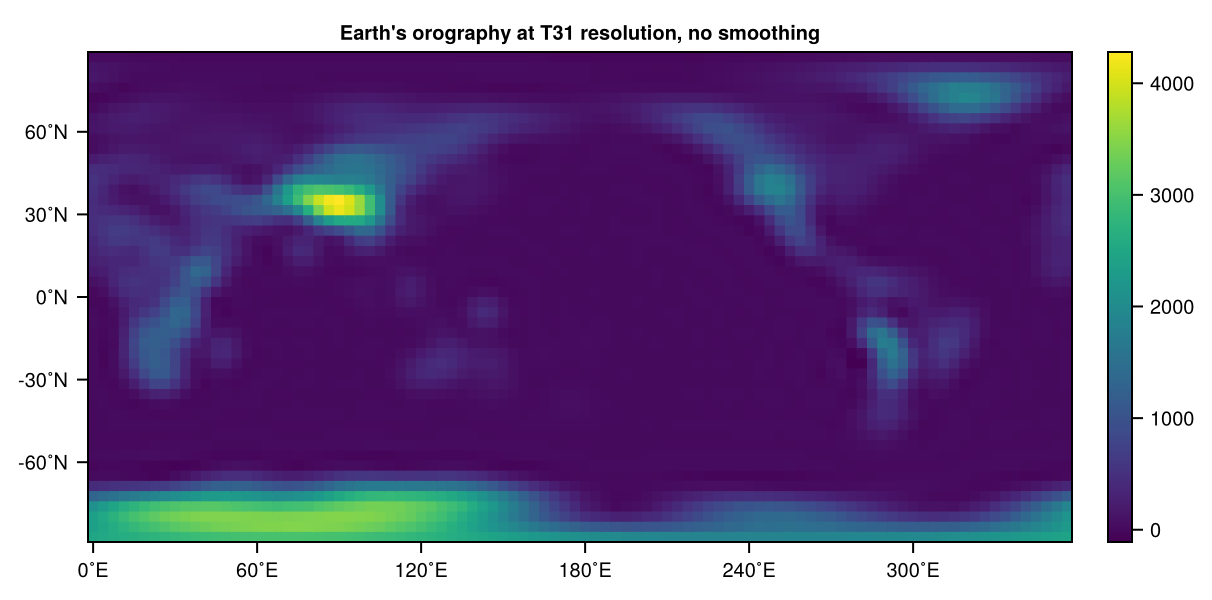

In [23]:
orography = EarthOrography(spectral_grid)
initialize!(orography, model)
heatmap(orography.orography, title="Earth's orography at T31 resolution, no smoothing")

In [9]:
using SpeedyWeather
# components
spectral_grid = SpectralGrid(trunc=31, nlayers=8)
output = NetCDFOutput(spectral_grid, PrimitiveWetModel, path="/Users/vidale/SpeedyWeather", id="Climate_No-Ocean-Evap", output_dt=Minute(180))
add!(output, SpeedyWeather.TemperatureOutput(), SpeedyWeather.LargeScalePrecipitationOutput(), SpeedyWeather.ConvectivePrecipitationOutput())  # output also temperature and precip
add!(output,SpeedyWeather.SurfaceFluxesOutput()...)

# Some parameterisation choices
large_scale_condensation = ImplicitCondensation(spectral_grid)
convection = SimplifiedBettsMiller(spectral_grid)

# create model, initialize, run
model = PrimitiveWetModel(spectral_grid; large_scale_condensation, convection, output=output)
simulation = initialize!(model)
#run!(simulation, period=Day(360), output=true)
run!(simulation, period=Day(10), output=true)

[ Info: Time step changed from 2400000 to 2700000 milliseconds (+12%) to match output frequency.
Weather is speedy: run 0037 100%|█████████| Time: 0:00:02 (1001.82 years/day)


                      Surface relative vorticity [1/s]                     
       ┌────────────────────────────────────────────────────────────┐ 8e⁻⁵ 
    90 │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ ┌──┐ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
    ˚N │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄│ │▄▄│ 
       │▄▄▄▄

## Optional approaches

In [24]:
using NCDatasets
ds = NCDataset("/Users/vidale/SpeedyWeather/run_0014/output.nc")
prec=1000*ds["precip_cond"]
lat=ds["lat"]
lon=ds["lon"]

lon (96)
  Datatype:    Float64 (Float64)
  Dimensions:  lon
  Attributes:
   units                = degrees_east
   long_name            = longitude
